In [ ]:
import kagglehub
path = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
print("Path to dataset files:", path)

100%|██████████| 428M/428M [00:20<00:00, 22.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1


In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout

In [ ]:
paths=[]
labels=[]
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1'):
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))
        label = filename[::-1].split('_')[0][::-1]
        labels.append(label.lower())
data = pd.DataFrame({'speech':paths,'label':labels})
x = data.sample(5)

In [ ]:
data['label'].value_counts()

,count
label,
neutral.wav,800
sad.wav,800
ps.wav,800
angry.wav,800
happy.wav,800
fear.wav,800
disgust.wav,800


In [ ]:
def waveplot(data,sr,emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion,size=20)
    librosa.display.waveshow(data,sr=sr)
    plt.show()

def spectogram(data,sr,emotion):
    x=librosa.stft(data)
    xdb=librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    librosa.display.specshow(xdb,sr=sr,x_axis='time',y_axis='hz')
    plt.colorbar()

def ana_emotion(emotion:str, df:pd.DataFrame):
    path=np.array(df['speech'][df['label']==emotion])[0]
    data,sampling_rate=librosa.load(path)
    waveplot(data,sampling_rate,emotion)
    spectogram(data,sampling_rate,emotion)
    display(Audio(path))

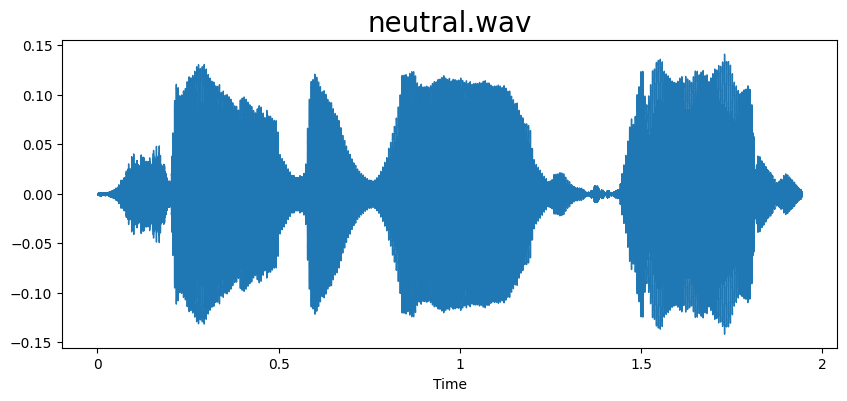

None

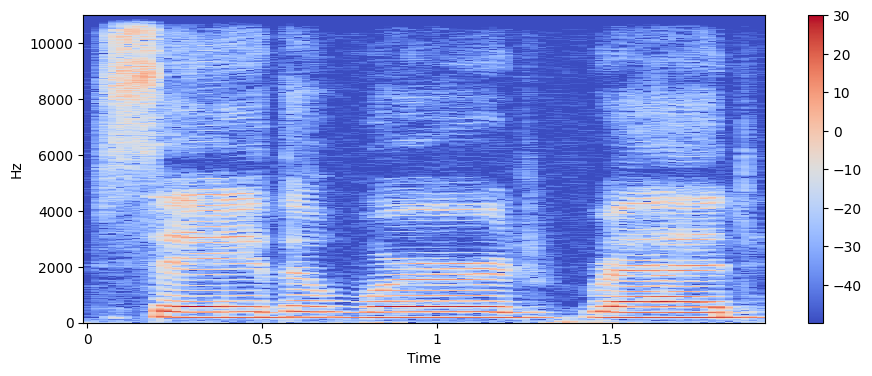

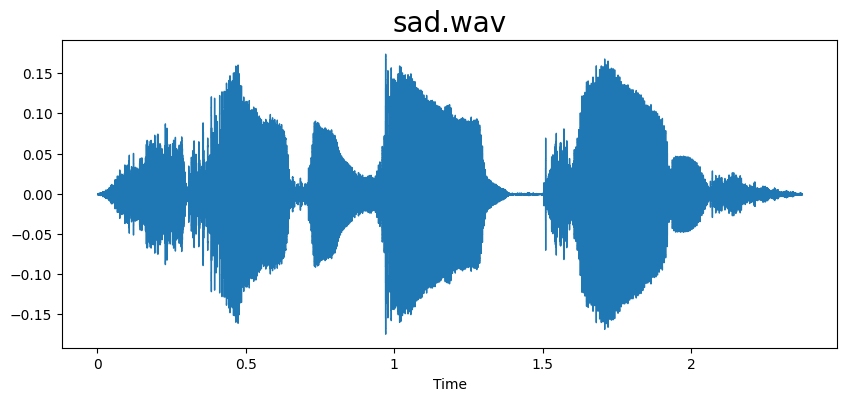

None

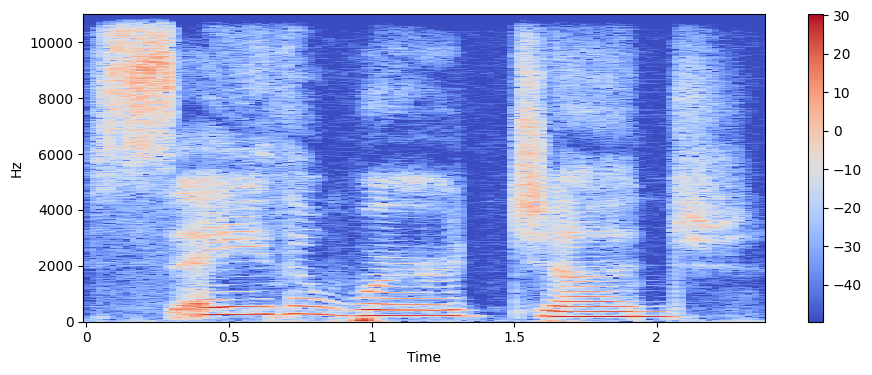

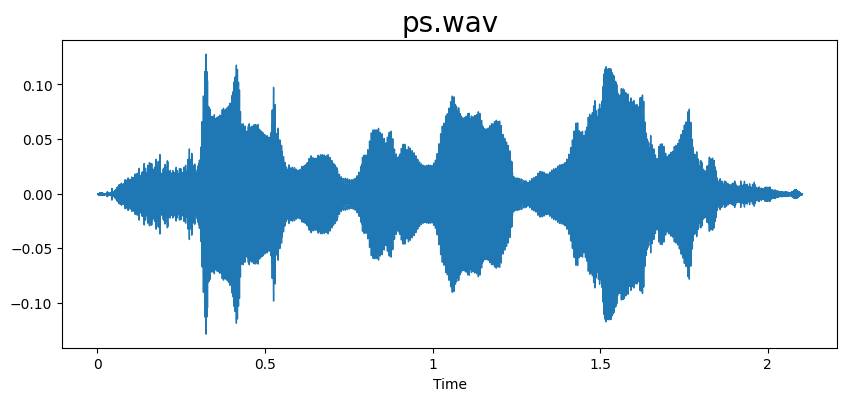

None

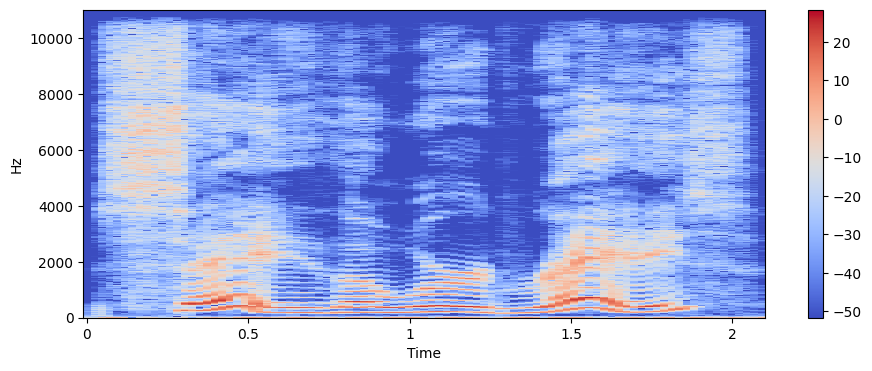

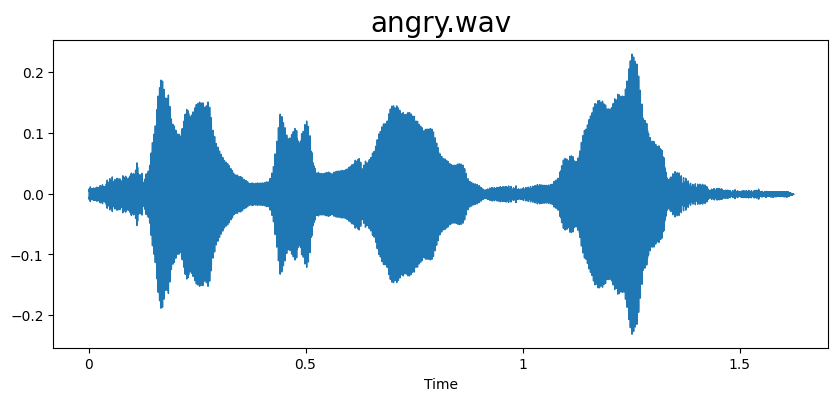

None

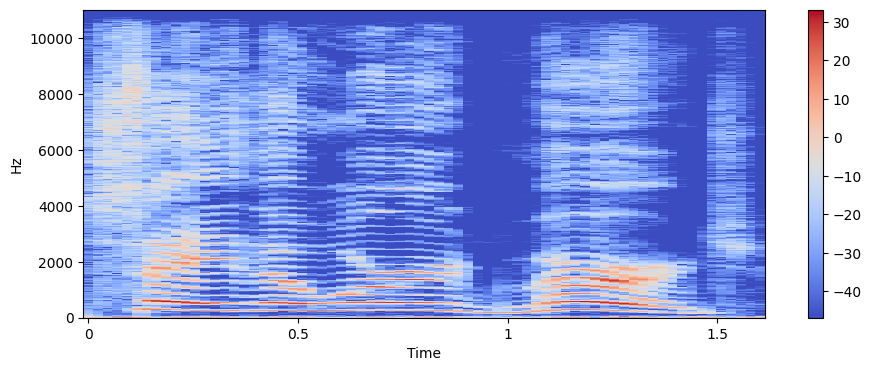

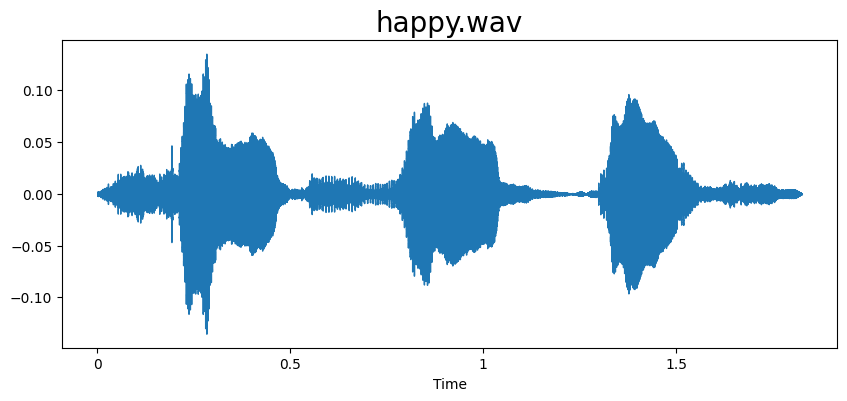

None

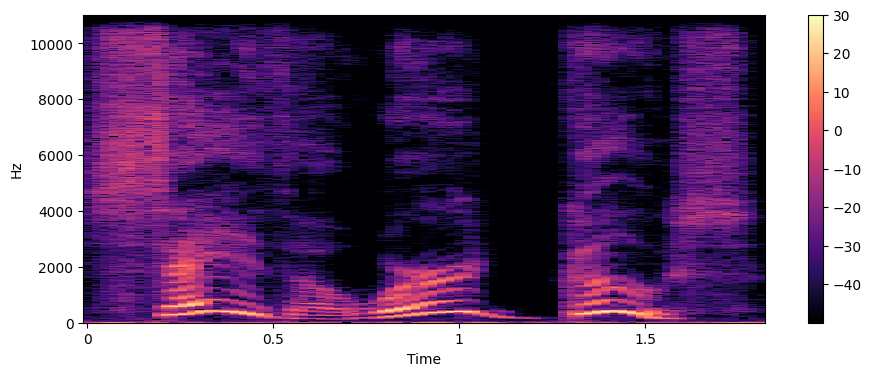

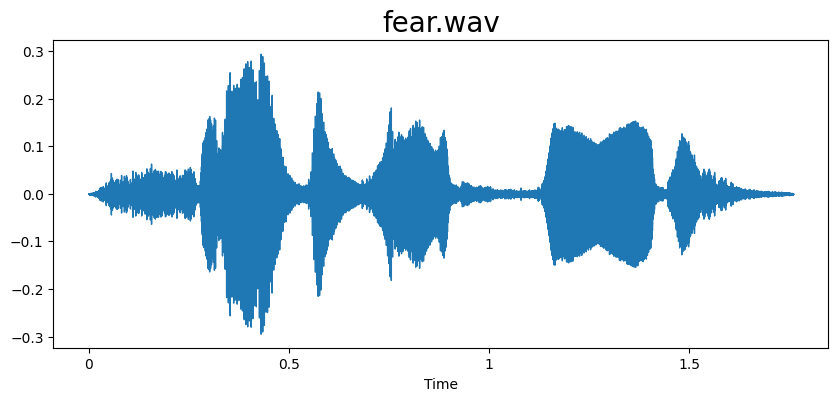

None

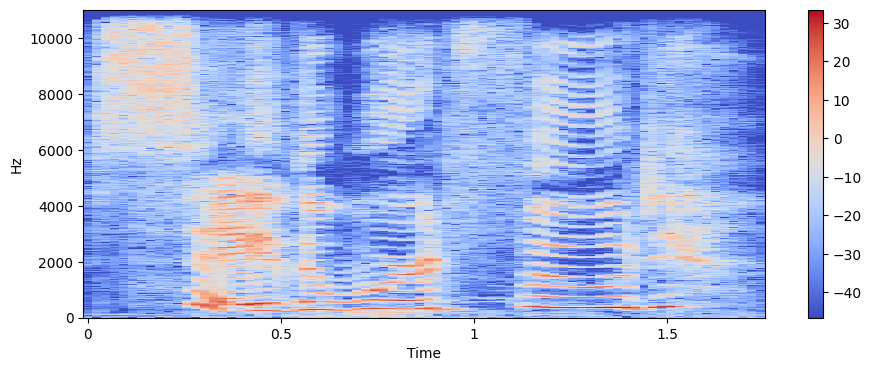

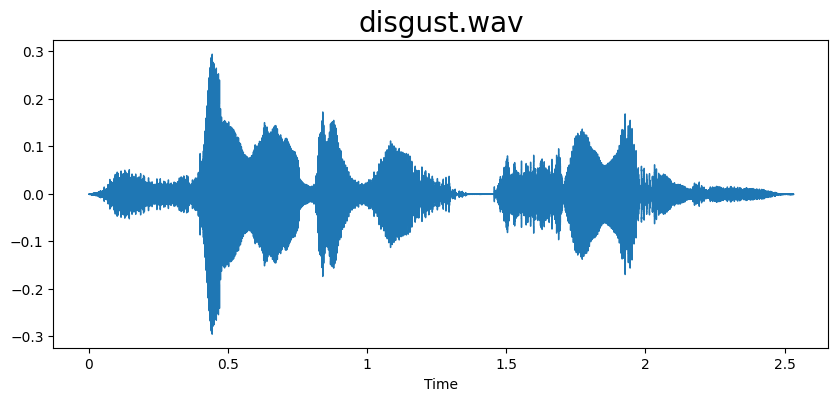

None

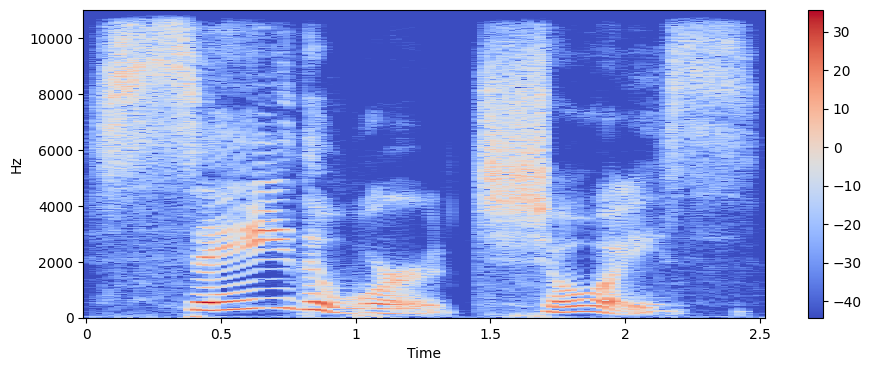

In [ ]:
for i in list(data['label'].unique()):
    display(ana_emotion(i, data))

## Read this resource
## [MFCC & PLP](https://jonathan-hui.medium.com/speech-recognition-feature-extraction-mfcc-plp-5455f5a69dd9)

In [ ]:
def MFCC(filename):
    y, sr = librosa.load(filename,duration=3,offset=0.5)
    return np.mean(librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40).T,axis=0)
mfcc= data['speech'].apply(lambda x:MFCC(x))

In [ ]:
mfcc

,speech
0,"[-410.1333, 107.65628, -3.8428848, 19.22418, 0..."
1,"[-417.50607, 96.82438, 4.726275, 34.086327, 6...."
2,"[-493.06287, 98.67417, 20.97822, 21.976233, 3...."
3,"[-420.40222, 80.02803, 6.293351, 32.179897, 2...."
4,"[-443.05917, 97.278885, 17.38711, 22.032476, -..."
...,...
5595,"[-519.2709, 99.49054, 32.848385, 7.6418743, 17..."
5596,"[-529.4069, 113.95791, 36.575027, 0.83247983, ..."
5597,"[-527.6302, 94.51841, 36.71682, 0.8460104, 10...."
5598,"[-521.01794, 119.734406, 28.029362, 1.2564013,..."


In [ ]:
X=[x for x in mfcc]
X=np.array(X)
X.shape
X=np.expand_dims(X,-1)
X.shape

(5600, 40, 1)

In [ ]:
ohe=OneHotEncoder()
y = ohe.fit_transform( data[['label']] )
y= y.toarray()

In [ ]:
model=Sequential([
    LSTM(256,return_sequences=False,input_shape=(40,1)),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(7,activation='softmax')
])
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 256)                 │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train the model
history=model.fit(X,y,validation_split=0.2,epochs=20,batch_size=64)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5153 - loss: 1.2619 - val_accuracy: 0.9134 - val_loss: 0.2755
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9223 - loss: 0.2396 - val_accuracy: 0.9527 - val_loss: 0.1425
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9631 - loss: 0.1345 - val_accuracy: 0.9652 - val_loss: 0.1035
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9529 - loss: 0.1484 - val_accuracy: 0.9196 - val_loss: 0.2455
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9742 - loss: 0.0978 - val_accuracy: 0.9089 - val_loss: 0.2527
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9724 - loss: 0.0914 - val_accuracy: 0.9750 - val_loss: 0.0847
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9805 - loss: 0.0609 - val_accuracy: 0.9741 - val_loss: 0.0725
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9727 - loss: 0.0830 - val_accuracy: 0.9732 - val_los

0.9910714030265808
0.9821428656578064


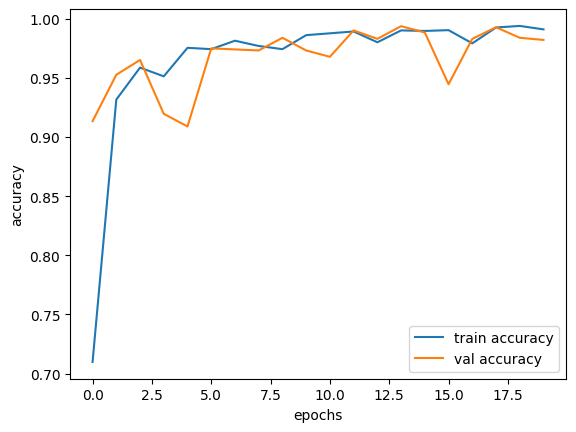

In [ ]:
epochs = list(range(20))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
print(acc[-1])
print(val_acc[-1])
plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
def predict_emotion(audio_path, model, ohe):

    y, sr = librosa.load(audio_path, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    mfcc = np.expand_dims(mfcc, axis=0)
    mfcc = np.expand_dims(mfcc, axis=-1)


    prediction = model.predict(mfcc)
    predicted_class = np.argmax(prediction, axis=1)


    label = ohe.inverse_transform(np.eye(7)[predicted_class])[0][0]
    return label

audio_file_path = '/content/OAF_bean_happy.wav'
predicted_emotion = predict_emotion(audio_file_path, model, ohe)
print(f"The predicted emotion is: {predicted_emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
The predicted emotion is: happy.wav
